# Decision Trees

In [10]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')

import Partitioner as part

# Fix the random seed for reproducibility
# !! Important !! : do not change this
seed = 1234
np.random.seed(seed)  

In [3]:
# Load dataset
X_tr, X_val, X_te, y_tr, y_val, y_te = part.getDefaultWineSets()

## Dataset Context

In [4]:
# Get Dataset Context
print(f"Number of samples: {X_tr.shape[0] + X_val.shape[0] + X_te.shape[0]}")
print(f"Features per sample: {X_tr.shape[1]}")

print(y_tr[:100])

Number of samples: 6497
Features per sample: 12
[6 7 5 6 7 5 9 7 6 6 6 7 6 6 5 6 6 5 5 5 6 6 5 5 5 7 4 6 6 6 6 6 7 6 6 6 6
 7 4 6 7 5 5 6 6 5 4 6 6 5 7 5 6 5 6 6 5 6 6 6 5 6 5 6 4 8 6 4 7 6 6 6 5 3
 7 5 5 6 5 6 5 7 7 6 6 7 5 6 5 7 5 5 6 6 5 6 5 6 6 8]


# Decision Tree With Default Parameters

Training error: 0.0
Validation error: 0.40692307692307694
Root feature index: 11
Root split threshold: 10.483333110809326


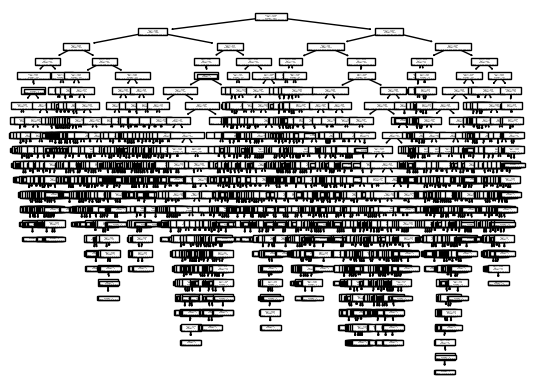

In [ ]:
# Decision tree classifier with default settings
model = DecisionTreeClassifier(random_state=seed)

model.fit(X_tr, y_tr)
err_tr = 1 - accuracy_score(y_tr, model.predict(X_tr))
err_val = 1 - accuracy_score(y_val, model.predict(X_val))

print(f"Training error: {err_tr}")
print(f"Validation error: {err_val}")

plot_tree(model)

print(f"Root feature index: {model.tree_.feature[0]}")
print(f"Root split threshold: {model.tree_.threshold[0]}")

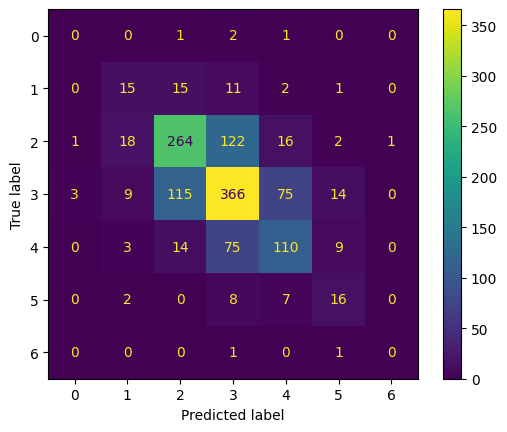

In [21]:
cm = confusion_matrix(y_val, model.predict(X_val))
sklearn_disp = ConfusionMatrixDisplay(confusion_matrix = cm)
sklearn_disp.plot();

#### Considering the values in the generated confusion matrix for a decision tree classifier with default sklearn settings, it appears that the mistakes made by the decision tree are generally small, with incorrectly predicted labels often being off by only one or two ranks. Since wine quality can be considered more of a subjective classifier, it may be within reason to group rankings that are close together into a single rank. This could be done by partitioning into low, medium, and high-quality labels

# Random Forest With Default Parameters

Training error: 0.0
Validation error: 0.33307692307692305


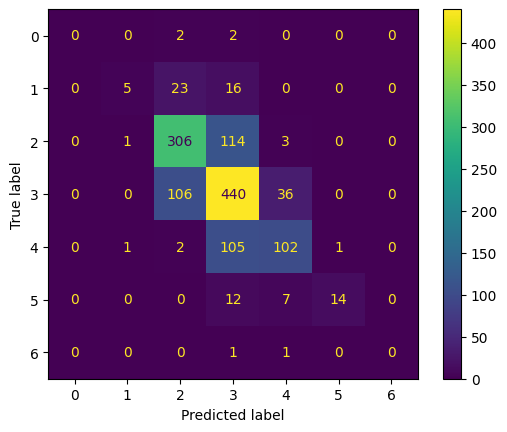

In [27]:
# Random forest classifier with default settings
model = RandomForestClassifier(random_state=seed)

model.fit(X_tr, y_tr)
err_tr = 1 - accuracy_score(y_tr, model.predict(X_tr))
err_val = 1 - accuracy_score(y_val, model.predict(X_val))

print(f"Training error: {err_tr}")
print(f"Validation error: {err_val}")

cm = confusion_matrix(y_val, model.predict(X_val))
sklearn_disp = ConfusionMatrixDisplay(confusion_matrix = cm)
sklearn_disp.plot();

#### When using a random forest instead of a single decision tree, the validation error is lower by roughly 7%, and the quality misclassifications are less spread out. That is to say, there are fewer mistakes made where the predicted label is relatively far from the actual label. This is consistent with what we learned in class about both bagging and random forests. Since trees are incapable of overfitting on data points and features that they don't have access to, the result is that the consolidated "votes" of each tree in the forest is a better generalization than a single tree alone would make when trained on the same data.

***

## Varying Minimum Leaf Samples

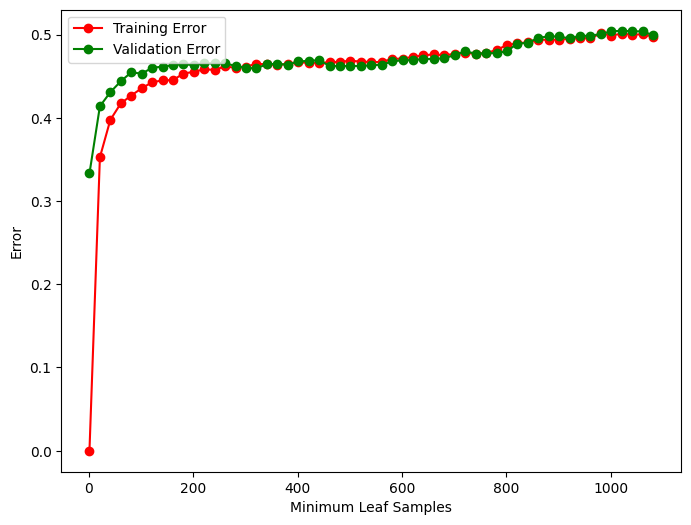

In [12]:
_, axes = plt.subplots(1, figsize=(8, 6))

min_samples_leaf = np.arange(1, 1101, 20)
err_tr = np.zeros_like(min_samples_leaf, dtype=float)
err_val = np.zeros_like(min_samples_leaf, dtype=float)

for i, min_samples in enumerate(min_samples_leaf):
    model = RandomForestClassifier(min_samples_leaf=min_samples, random_state=seed)

    model.fit(X_tr, y_tr)
    err_tr[i] = 1 - accuracy_score(y_tr, model.predict(X_tr))
    err_val[i] = 1 - accuracy_score(y_val, model.predict(X_val))

axes.plot(min_samples_leaf, err_tr, marker='o', c='red', label="Training Error")
axes.plot(min_samples_leaf, err_val, marker='o', c='green', label="Validation Error")
axes.set_xlabel("Minimum Leaf Samples")
axes.set_ylabel("Error")
axes.legend();

Training error: 0.0
Validation error: 0.33307692307692305


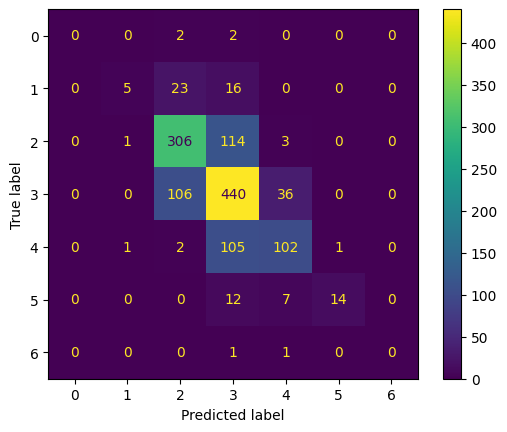

In [10]:

model = RandomForestClassifier(min_samples_leaf=1, random_state=seed)

model.fit(X_tr, y_tr)
err_tr = 1 - accuracy_score(y_tr, model.predict(X_tr))
err_val = 1 - accuracy_score(y_val, model.predict(X_val))

print(f"Training error: {err_tr}")
print(f"Validation error: {err_val}")

cm = confusion_matrix(y_val, model.predict(X_val))
sklearn_disp = ConfusionMatrixDisplay(confusion_matrix = cm)
sklearn_disp.plot();

#### When considering different numbers of minimum leaf samples, it appears that the validation accuracy is at its highest when the parameter is set to 1. This, to me, is somewhat of a surprising result, since the purpose of varying the minimum number of leaf samples is to reduce overfitting. However, it may be that the generalization introduced when using a random forest is already sufficient for classification and that further regularization, therefore, would lead to making the model too simple. In an attempt to verify this hypothesis, I will next see what effect varying the leaf samples has on a decision tree alone when training with this data set.

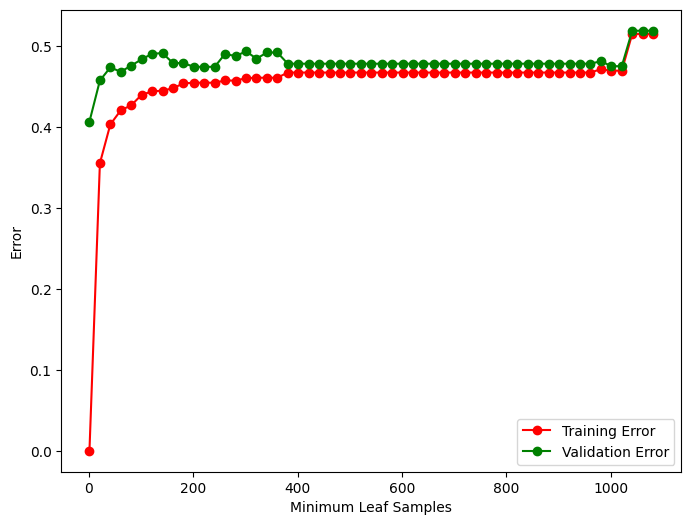

In [13]:
_, axes = plt.subplots(1, figsize=(8, 6))

min_samples_leaf = np.arange(1, 1101, 20)
err_tr = np.zeros_like(min_samples_leaf, dtype=float)
err_val = np.zeros_like(min_samples_leaf, dtype=float)

for i, min_samples in enumerate(min_samples_leaf):
    model = DecisionTreeClassifier(min_samples_leaf=min_samples, random_state=seed)

    model.fit(X_tr, y_tr)
    err_tr[i] = 1 - accuracy_score(y_tr, model.predict(X_tr))
    err_val[i] = 1 - accuracy_score(y_val, model.predict(X_val))

axes.plot(min_samples_leaf, err_tr, marker='o', c='red', label="Training Error")
axes.plot(min_samples_leaf, err_val, marker='o', c='green', label="Validation Error")
axes.set_xlabel("Minimum Leaf Samples")
axes.set_ylabel("Error")
axes.legend();

#### Comparing minimum leaf samples with a single decision tree has revealed behavior similar to that of a random forest in that the validation error only increases along with the minimum leaf samples parameter. This implies that it is not an overgeneralization by the random forest that occurs, but it is rather that the data itself is complex enough to warrant splits based on singular data points. 

***

## Varying Minimum Samples to Split

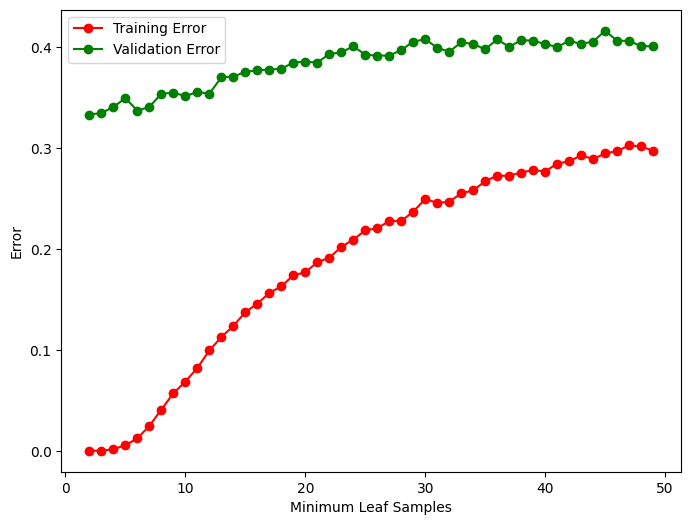

In [6]:
_, axes = plt.subplots(1, figsize=(8, 6))

min_samples_split = np.arange(2, 50, 1)
err_tr = np.zeros_like(min_samples_split, dtype=float)
err_val = np.zeros_like(min_samples_split, dtype=float)

for i, min_samples in enumerate(min_samples_split):
    model = RandomForestClassifier(min_samples_split=min_samples, random_state=seed)

    model.fit(X_tr, y_tr)
    err_tr[i] = 1 - accuracy_score(y_tr, model.predict(X_tr))
    err_val[i] = 1 - accuracy_score(y_val, model.predict(X_val))

axes.plot(min_samples_split, err_tr, marker='o', c='red', label="Training Error")
axes.plot(min_samples_split, err_val, marker='o', c='green', label="Validation Error")
axes.set_xlabel("Minimum Leaf Samples")
axes.set_ylabel("Error")
axes.legend();

#### In light of the effects of setting the minimum number of samples per leaf, it's not surprising that the validation error increases along with the minimum number of samples required to split, even though this parameter is less restrictive than the minimum number of leaf nodes.

# [TODO]: DECISION TREE VS. RANDOM FOREST FOR THIS CATEGORY

***

## Varying Maximum Depth

The best maximum depth was 22 with a validation error of 0.40384615384615385.


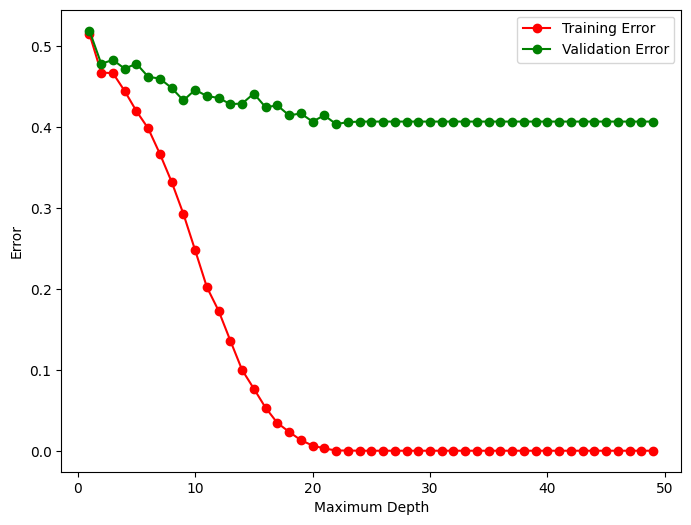

In [16]:
_, axes = plt.subplots(1, figsize=(8, 6))

max_depth = np.arange(1, 50, 1)
err_tr = np.zeros_like(max_depth, dtype=float)
err_val = np.zeros_like(max_depth, dtype=float)

min_error = 1
best_max_depth = 1

for i, depth in enumerate(max_depth):
    model = DecisionTreeClassifier(max_depth=depth, random_state=seed)

    model.fit(X_tr, y_tr)
    err_tr[i] = 1 - accuracy_score(y_tr, model.predict(X_tr))
    err_val[i] = 1 - accuracy_score(y_val, model.predict(X_val))

    if err_val[i] < min_error:
        min_error = err_val[i]
        best_max_depth = i+1

print(f"The best maximum depth was {max_depth[best_max_depth-1]} with a validation error of {err_val[best_max_depth-1]}.")

axes.plot(max_depth, err_tr, marker='o', c='red', label="Training Error")
axes.plot(max_depth, err_val, marker='o', c='green', label="Validation Error")
axes.set_xlabel("Maximum Depth")
axes.set_ylabel("Error")
axes.legend();

#### When using a single decision tree, the maximum depth parameter that produces the best value is 22, and the error plateaus starting at a maximum depth of 23, at which point the training error also plataus at 0. This reinforces the understanding that the smaller nuances in the data are important to consider when making classificaitons.

The best maximum depth was 19 with a validation error of 0.3261538461538461.


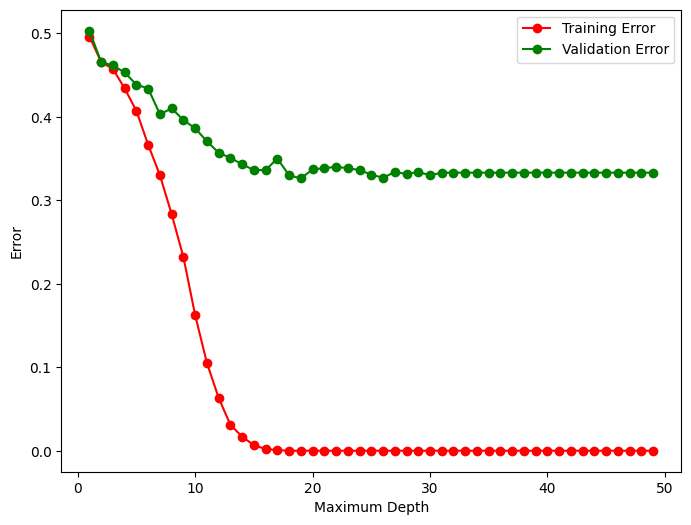

In [17]:
_, axes = plt.subplots(1, figsize=(8, 6))

max_depth = np.arange(1, 50, 1)
err_tr = np.zeros_like(max_depth, dtype=float)
err_val = np.zeros_like(max_depth, dtype=float)

min_error = 1
best_max_depth = 1

for i, depth in enumerate(max_depth):
    model = RandomForestClassifier(max_depth=depth, random_state=seed)

    model.fit(X_tr, y_tr)
    err_tr[i] = 1 - accuracy_score(y_tr, model.predict(X_tr))
    err_val[i] = 1 - accuracy_score(y_val, model.predict(X_val))

    if err_val[i] < min_error:
        min_error = err_val[i]
        best_max_depth = i+1

print(f"The best maximum depth was {max_depth[best_max_depth-1]} with a validation error of {err_val[best_max_depth-1]}.")

axes.plot(max_depth, err_tr, marker='o', c='red', label="Training Error")
axes.plot(max_depth, err_val, marker='o', c='green', label="Validation Error")
axes.set_xlabel("Maximum Depth")
axes.set_ylabel("Error")
axes.legend();

#### When it comes to random forests, the maximum depth that produced the smallest validation error was 19. Since this is less than the best maximum depth for a decision tree alone, it would seem that the individual trees of a random forest are more sensitive to noise in the samples and features they have access to at a given point. This could possibly be explained by the limited number of data points and features at a given point leading to overfitting on noise for the individual trees. While this noise is generally mitigated by the ensemble, performance is slightly improved by having a smaller maximum depth per tree to mitigate noise even further.

***

## Varying Score Functions

The best score function was gini with a validation error of 0.33307692307692305.


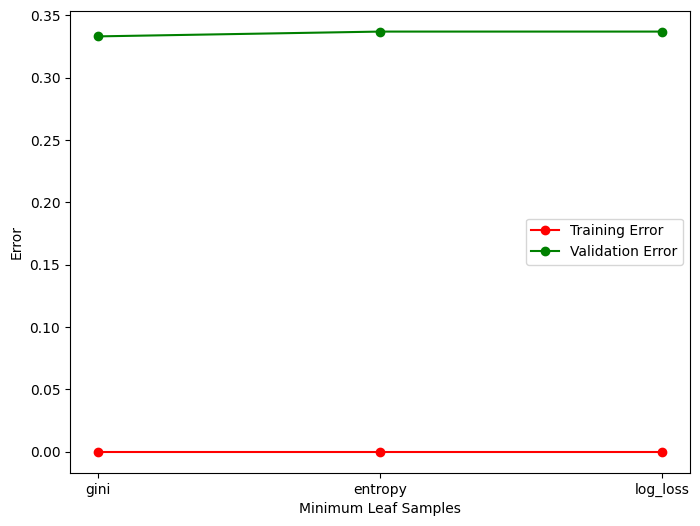

In [9]:
_, axes = plt.subplots(1, figsize=(8, 6))

score = ["gini", "entropy", "log_loss"]
err_tr = np.zeros_like(score, dtype=float)
err_val = np.zeros_like(score, dtype=float)

min_error = 1
best_function = 1

for i, func in enumerate(score):
    model = RandomForestClassifier(criterion=func, random_state=seed)

    model.fit(X_tr, y_tr)
    err_tr[i] = 1 - accuracy_score(y_tr, model.predict(X_tr))
    err_val[i] = 1 - accuracy_score(y_val, model.predict(X_val))

    if err_val[i] < min_error:
        min_error = err_val[i]
        best_function = i+1

print(f"The best score function was {score[best_function-1]} with a validation error of {err_val[best_function-1]}.")

axes.plot(score, err_tr, marker='o', c='red', label="Training Error")
axes.plot(score, err_val, marker='o', c='green', label="Validation Error")
axes.set_xlabel("Minimum Leaf Samples")
axes.set_ylabel("Error")
axes.legend();

## Grid Search on Best Values

In [11]:
params = {
    "max_depth": [10, 19, 22, None],
    "min_samples_split": [1, 3, 5, 6],
    "criterion": ["gini", "entropy", "log_loss"]
}

Tree training error: 0.026943802925327165
Tree validation error: 0.4146153846153846
Root feature index: 11
Root split threshold: 10.483333110809326


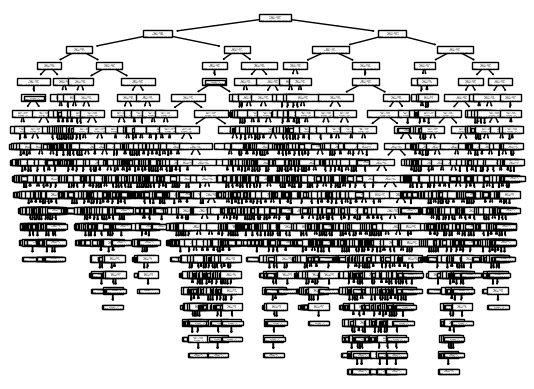

In [14]:
tree_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=seed),
    params,
    cv=5,
    scoring="accuracy"
)

tree_grid.fit(X_tr, y_tr)

tree_err_tr = 1 - accuracy_score(y_tr, tree_grid.predict(X_tr))
tree_err_val = 1 - accuracy_score(y_val, tree_grid.predict(X_val))

print(f"Tree training error: {tree_err_tr}")
print(f"Tree validation error: {tree_err_val}")

plot_tree(tree_grid.best_estimator_)
print(f"Root feature index: {tree_grid.best_estimator_.tree_.feature[0]}")
print(f"Root split threshold: {tree_grid.best_estimator_.tree_.threshold[0]}")

In [15]:
forest_grid = GridSearchCV(
    RandomForestClassifier(random_state=seed),
    params,
    cv=5,
    scoring="accuracy"
)
 
forest_grid.fit(X_tr, y_tr)

forest_err_tr = 1 - accuracy_score(y_tr, forest_grid.predict(X_tr))
forest_err_val = 1 - accuracy_score(y_val, forest_grid.predict(X_val))

print(f"Forest training error: {forest_err_tr}")
print(f"Forest validation error: {forest_err_tr}")

Forest training error: 0.005388760585065433
Forest validation error: 0.005388760585065433


In [16]:
print(forest_grid.best_params_)

{'criterion': 'gini', 'max_depth': 22, 'min_samples_split': 5}


# [TODO]: COMMENT ON RESULTS

# [TODO]: CONFUSION MATRICES FOR EACH ADDITIONAL EXPERIMENT